## Merge `top_boundaries.py` output onto raw paragraphs

Base dataframe for everything below: paragraph content plus the rule-based TOP
boundary detector's per-paragraph output (`top_seq`, `top_number_raw`,
`top_doc_type`, `top_sponsor`).

In [1]:
import os
import pandas as pd

data_root = os.environ['DATA_ROOT']
paras = pd.read_parquet(os.path.join(data_root, "raw/stateparl_v3_parquet/stateparl_v3_paragraphs.parquet"))
top = pd.read_parquet(os.path.join(data_root, "processed/top_boundaries.parquet"))
df = paras.merge(top, on="paragraph_id", how="left")

In [2]:
df.describe()

,paragraph_id,period,nth,protocol_position_x,segment_position,page,protocol_position_y,top_seq
count,1.607847e+07,1.607847e+07,1.607847e+07,1.607847e+07,1.607847e+07,1.607847e+07,1.607847e+07,1.607847e+07
mean,8.085395e+06,1.317759e+01,6.181801e+01,9.983108e+02,1.701656e+01,5.151377e+01,9.983108e+02,4.438036e+00
std,4.665478e+06,5.536742e+00,3.746077e+01,7.091159e+02,2.607556e+01,3.566555e+01,7.091159e+02,4.641140e+00
min,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,4.052334e+06,7.000000e+00,3.100000e+01,4.310000e+02,4.000000e+00,2.400000e+01,4.310000e+02,1.000000e+00
50%,8.091652e+06,1.500000e+01,5.800000e+01,8.850000e+02,1.000000e+01,4.500000e+01,8.850000e+02,3.000000e+00
75%,1.212712e+07,1.700000e+01,8.900000e+01,1.432000e+03,2.000000e+01,7.100000e+01,1.432000e+03,7.000000e+00
max,1.616890e+07,2.200000e+01,1.700000e+02,5.938000e+03,1.053000e+03,3.940000e+02,5.938000e+03,6.300000e+01


In [3]:
print(df.columns)
df.drop(columns=["protocol_id_y", "protocol_position_y"], inplace=True)
df.rename(columns={"protocol_id_x": "protocol_id", "protocol_position_x": "protocol_position"}, inplace=True)

Index(['paragraph_id', 'protocol_id_x', 'state', 'period', 'nth', 'date',
       'speech_id', 'protocol_position_x', 'segment_position', 'page',
       'speaker_paragraph', 'mandate_id', 'affiliation', 'content',
       'protocol_id_y', 'protocol_position_y', 'top_seq', 'top_number_raw',
       'top_doc_type', 'top_sponsor'],
      dtype='str')


In [4]:
df.head(20)

,paragraph_id,protocol_id,state,period,nth,date,speech_id,protocol_position,segment_position,page,speaker_paragraph,mandate_id,affiliation,content,top_seq,top_number_raw,top_doc_type,top_sponsor
0,1,bb_3_10,bb,3,10,2000-02-24,NaN,1,2,4,Knoblich,bb_3_pre_knoblich,pre,Werte Kolleginnen und Kollegen! Ich begrüße Si...,0,,,
1,2,bb_3_10,bb,3,10,2000-02-24,NaN,2,3,4,,,nsc,(Allgemeiner Beifall),0,,,
2,3,bb_3_10,bb,3,10,2000-02-24,NaN,3,4,4,Knoblich,bb_3_pre_knoblich,pre,Nicht weniger herzlich begrüße ich unsere Stam...,0,,,
3,4,bb_3_10,bb,3,10,2000-02-24,NaN,4,5,4,Knoblich,bb_3_pre_knoblich,pre,Mit der Einladung ist Ihnen der Vorschlag zur ...,0,,,
4,5,bb_3_10,bb,3,10,2000-02-24,NaN,5,6,4,Knoblich,bb_3_pre_knoblich,pre,"Ich darf darauf hinweisen, dass die DVU-Frakti...",0,,,
5,6,bb_3_10,bb,3,10,2000-02-24,NaN,6,7,4,Knoblich,bb_3_pre_knoblich,pre,Damit darf ich um Ihr zustimmendes Handzeichen...,0,,,
6,7,bb_3_10,bb,3,10,2000-02-24,NaN,7,8,4,Knoblich,bb_3_pre_knoblich,pre,"Ich merke gerade, dass es notwendig gewesen wä...",0,,,
7,8,bb_3_10,bb,3,10,2000-02-24,NaN,8,9,4,Knoblich,bb_3_pre_knoblich,pre,"Es wird vorgeschlagen, einen neuen Tagesordnun...",0,,,
8,9,bb_3_10,bb,3,10,2000-02-24,NaN,9,10,4,Knoblich,bb_3_pre_knoblich,pre,Außerdem wird ein neuer Tagesordnungspunkt 11 ...,0,,,
9,10,bb_3_10,bb,3,10,2000-02-24,NaN,10,11,4,Knoblich,bb_3_pre_knoblich,pre,"Schließlich wird vorgeschlagen, einen Tagesord...",0,,,


In [5]:
prot = pd.read_parquet(os.path.join(data_root, "raw/stateparl_v3_parquet/stateparl_v3_protocols.parquet"))
df = df.merge(prot[["protocol_id", "url"]], on="protocol_id", how="left")

## Corpus coverage check

Protocols per state/year, to see where gaps are before drawing an annotation
sample.

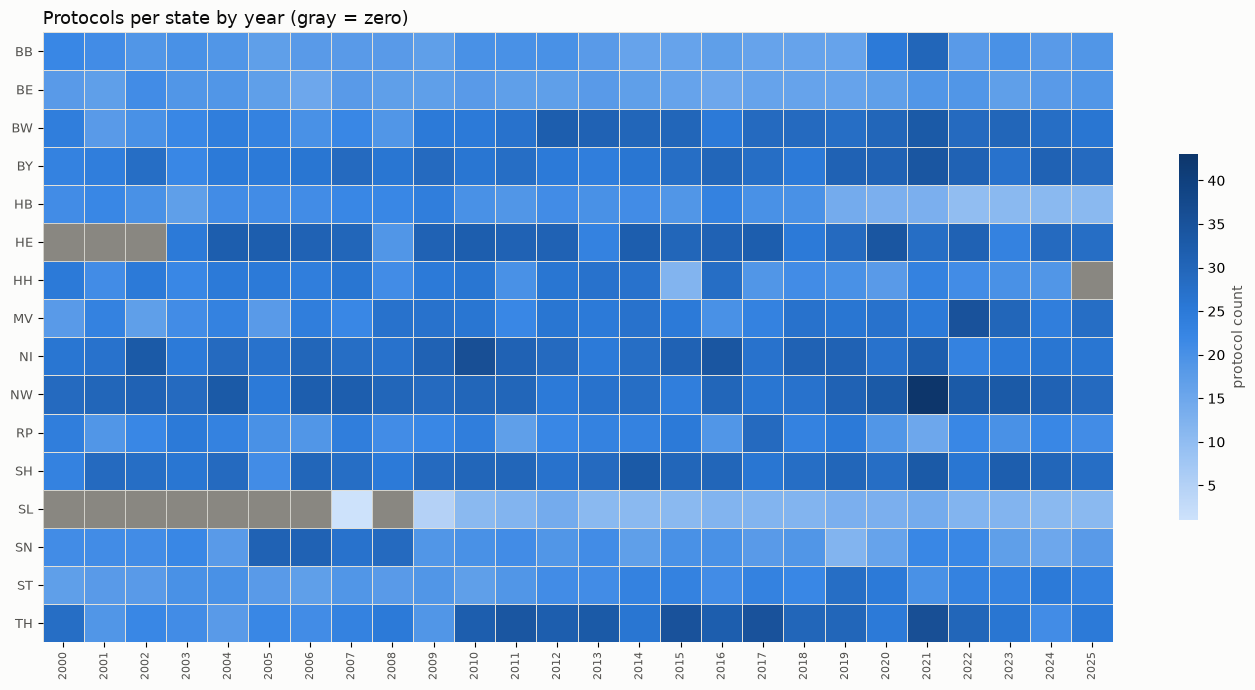

In [6]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, "../..")
from utils.colors import SEQ_BLUES, CHROME

prot["year"] = pd.to_datetime(prot["date"]).dt.year
counts = prot.groupby(["state", "year"]).size().unstack(fill_value=0)

all_years = list(range(int(prot["year"].min()), int(prot["year"].max()) + 1))
all_states = sorted(prot["state"].unique())
counts = counts.reindex(index=all_states, columns=all_years, fill_value=0)

ramp = [SEQ_BLUES[k] for k in sorted(SEQ_BLUES)]
cmap = mcolors.LinearSegmentedColormap.from_list("seq_blues", ramp)

fig, ax = plt.subplots(figsize=(14, 7), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])

values = counts.values.astype(float)
masked = np.ma.masked_equal(values, 0)
mesh = ax.pcolormesh(masked, cmap=cmap, edgecolors=CHROME["gridline"], linewidth=0.5)

# zero cells get a flat, distinct fill -- not the palest ramp step -- since
# telling "no protocols" apart from "one protocol" is the point of this chart
zero_rows, zero_cols = np.where(values == 0)
for r, c in zip(zero_rows, zero_cols):
    ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=CHROME["ink_muted"],
                                edgecolor=CHROME["gridline"], linewidth=0.5))

ax.set_xticks(np.arange(len(all_years)) + 0.5)
ax.set_xticklabels(all_years, rotation=90, fontsize=8, color=CHROME["ink_secondary"])
ax.set_yticks(np.arange(len(all_states)) + 0.5)
ax.set_yticklabels([s.upper() for s in all_states], fontsize=9, color=CHROME["ink_secondary"])
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Protocols per state by year (gray = zero)", loc="left",
             color=CHROME["ink_primary"], fontsize=13)

cbar = fig.colorbar(mesh, ax=ax, shrink=0.6, label="protocol count")
cbar.ax.yaxis.label.set_color(CHROME["ink_secondary"])
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

## Spot-check the rule-based detector

Eyeball one random protocol per state to see if `top_boundaries.py`'s TOP
splits look sane before trusting them to build the annotation sample.

In [7]:
def inspect_protocol(protocol_id):
    print(f"url: {df.loc[df['protocol_id'] == protocol_id, 'url'].iloc[0]}")
    tops = (
        df[(df["protocol_id"] == protocol_id) & (df["top_seq"] > 0)]
        .drop_duplicates(["protocol_id", "top_seq"])
        .sort_values("top_seq")
    )
    for _, row in tops.iterrows():
        print(f"  seq={row.top_seq} num={row.top_number_raw!r} type={row.top_doc_type!r} sponsor={row.top_sponsor!r}")

# pick a random protocol per state to spot-check
sample_ids = df.drop_duplicates("protocol_id").groupby("state")["protocol_id"].apply(lambda s: s.sample(1)).tolist()
for pid in sample_ids:
    print(f"\n===== protocol {pid} =====")
    inspect_protocol(pid)


===== protocol bb_8_20 =====
url: https://assets.stateparl.de/protocols/bb_8_20.pdf
  seq=1 num='1' type='' sponsor=''
  seq=2 num='2' type='' sponsor=''
  seq=3 num='3' type='' sponsor=''
  seq=4 num='3' type='' sponsor=''
  seq=5 num='3' type='' sponsor=''
  seq=6 num='7' type='' sponsor=''
  seq=7 num='7' type='' sponsor=''
  seq=8 num='8' type='' sponsor=''
  seq=9 num='' type='' sponsor=''
  seq=10 num='10' type='' sponsor=''
  seq=11 num='11' type='' sponsor=''
  seq=12 num='11' type='' sponsor=''
  seq=13 num='13' type='' sponsor=''
  seq=14 num='14' type='' sponsor=''
  seq=15 num='14' type='' sponsor=''

===== protocol be_18_3 =====
url: https://assets.stateparl.de/protocols/be_18_3.pdf

===== protocol bw_14_27 =====
url: https://assets.stateparl.de/protocols/bw_14_27.pdf
  seq=1 num='1' type='' sponsor=''
  seq=2 num='2' type='' sponsor=''
  seq=3 num='3' type='Beschlussempfehlung und Bericht' sponsor='Innenausschusses –'
  seq=4 num='3' type='' sponsor=''
  seq=5 num='4' ty

In [8]:
pre_cols = ["content", "affiliation", "mandate_id", "speaker_paragraph", "page", "date", "state", "protocol_id", "paragraph_id"]
pre_only = df.loc[df["affiliation"] == "pre", pre_cols]
pre_only.head(20)

,content,affiliation,mandate_id,speaker_paragraph,page,date,state,protocol_id,paragraph_id
0,Werte Kolleginnen und Kollegen! Ich begrüße Si...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,1
2,Nicht weniger herzlich begrüße ich unsere Stam...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,3
3,Mit der Einladung ist Ihnen der Vorschlag zur ...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,4
4,"Ich darf darauf hinweisen, dass die DVU-Frakti...",pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,5
5,Damit darf ich um Ihr zustimmendes Handzeichen...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,6
6,"Ich merke gerade, dass es notwendig gewesen wä...",pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,7
7,"Es wird vorgeschlagen, einen neuen Tagesordnun...",pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,8
8,Außerdem wird ein neuer Tagesordnungspunkt 11 ...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,9
9,"Schließlich wird vorgeschlagen, einen Tagesord...",pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,10
10,Hat noch jemand etwas vergessen? - Die anderen...,pre,bb_3_pre_knoblich,Knoblich,4,2000-02-24,bb,bb_3_10,11


## Build the annotation sample

Stratified: 3 protocols per state, spread across the early/middle/late third
of that state's date range, to catch state- and era-specific phrasing drift
rather than relying on pure random draws.

In [9]:
# Stratified sample of protocols: 3 per state, spread across each state's date
# range (earliest/middle/latest third) rather than pure random -- catches both
# state-specific and era-specific formatting drift.
import numpy as np

rng = np.random.default_rng(42)

protocols_meta = prot.copy()
protocols_meta["date"] = pd.to_datetime(protocols_meta["date"])

sampled = []
for state, group in protocols_meta.groupby("state"):
    group = group.sort_values("date")
    n = len(group)
    for idx in np.array_split(np.arange(n), 3):
        if len(idx):
            bucket = group.iloc[idx]
            sampled.append(bucket.sample(1, random_state=rng.integers(1_000_000)))

sample_protocols = pd.concat(sampled).reset_index(drop=True)
sample_protocols[["protocol_id", "state", "date", "url"]]

,protocol_id,state,date,url
0,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf
1,bb_5_81,bb,2013-09-25,https://assets.stateparl.de/protocols/bb_5_81.pdf
2,bb_7_34,bb,2021-01-28,https://assets.stateparl.de/protocols/bb_7_34.pdf
3,be_15_85,be,2006-05-04,https://assets.stateparl.de/protocols/be_15_85...
4,be_18_9,be,2017-04-06,https://assets.stateparl.de/protocols/be_18_9.pdf
5,be_18_21,be,2018-01-25,https://assets.stateparl.de/protocols/be_18_21...
6,bw_12_103,bw,2001-02-01,https://assets.stateparl.de/protocols/bw_12_10...
7,bw_16_31,bw,2017-04-06,https://assets.stateparl.de/protocols/bw_16_31...
8,bw_17_93,bw,2024-04-18,https://assets.stateparl.de/protocols/bw_17_93...
9,by_15_79,by,2006-11-10,https://assets.stateparl.de/protocols/by_15_79...


In [10]:
# All "pre" (presiding officer) paragraphs from within the sampled protocols.
# top_seq/top_number_raw/top_doc_type are kept here for the post-annotation
# comparison, but deliberately NOT shown during annotation itself (see below).
sample_ids = set(sample_protocols["protocol_id"])
annotation_cols = [
    "paragraph_id", "protocol_id", "protocol_position", "state", "date", "page",
    "mandate_id", "speaker_paragraph", "affiliation", "content",
    "top_seq", "top_number_raw", "top_doc_type", "url",
]
annotation_data = (
    df.loc[df["protocol_id"].isin(sample_ids) & (df["affiliation"] == "pre"), annotation_cols]
    .sort_values(["state", "date", "protocol_position"])
    .reset_index(drop=True)
)
annotation_data.head(20)

,paragraph_id,protocol_id,protocol_position,state,date,page,mandate_id,speaker_paragraph,affiliation,content,top_seq,top_number_raw,top_doc_type,url
0,116297,bb_4_14,1,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Meine sehr geehrten Damen und Herren! Liebe Ko...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
1,116298,bb_4_14,2,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Gesetz über die Feststellung des Haushaltsplan...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
2,116299,bb_4_14,3,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Ich rufe auf:,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
3,116300,bb_4_14,4,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Einzelplan 08 - Ministerium für Wirtschaft,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
4,116301,bb_4_14,5,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Beschlussempfehlung und Bericht des Ausschusse...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
5,116302,bb_4_14,6,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Drucksache 4/1108,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
6,116303,bb_4_14,7,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Der Haushaltsplan des Wirtschaftsministeriums ...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
7,116304,bb_4_14,8,bb,2005-05-19,4,bb_4_pre_fritsch,Fritsch,pre,Ich erteile das Wort an die DVU-Fraktion. Es s...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
8,116346,bb_4_14,50,bb,2005-05-19,6,bb_4_pre_fritsch,Fritsch,pre,Wir setzen mit dem Redebeitrag der SPD-Fraktio...,0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf
9,116370,bb_4_14,74,bb,2005-05-19,8,bb_4_pre_fritsch,Fritsch,pre,"Vielen Dank, Herr Müller. - Wir setzen die Ber...",0,,,https://assets.stateparl.de/protocols/bb_4_14.pdf


## Export gold-label input

Every `pre` paragraph from the sampled protocols → `top_boundaries_annotation_input.csv`,
the file `labelling/top_boundaries_annotator.py` reads.

In [11]:
# One row per raw "pre" paragraph -- no joining of consecutive rows.
contributions = (
    annotation_data[["protocol_id", "state", "date", "url", "protocol_position", "content"]]
    .rename(columns={"protocol_position": "start_pos"})
    .copy()
)
contributions["end_pos"] = contributions["start_pos"]
contributions = contributions[["protocol_id", "state", "date", "url", "start_pos", "end_pos", "content"]]
contributions.to_csv("../../labelling/top_boundaries_annotation_input.csv", index=False)
print(f"Exported {len(contributions)} pre paragraphs from {contributions['protocol_id'].nunique()} protocols.")
print("Now run: norm_env/bin/python labelling/top_boundaries_annotator.py")

Exported 13031 pre paragraphs from 47 protocols.
Now run: norm_env/bin/python labelling/top_boundaries_annotator.py


## Version 2 sample: one more protocol per state/stratum

Random expansion of the annotation set, minimum size: one additional protocol
per state × temporal-stratum cell (16 states × 3 date-thirds = 48 cells),
drawn only from protocols not already in `top_boundaries_annotation_input.csv`.
Written as **separate** `top_boundaries_annotation_input_v2.csv` /
`top_boundaries_opener_labels_v2.csv` files, not appended into the v1 files —
run `top_boundaries_annotator.py` against these explicitly when ready to
annotate them (it doesn't pick them up automatically).

In [ ]:
# Same date-third bucketing as v1 (so the strata line up), but each bucket's
# candidate pool excludes protocols already present in the existing input CSV,
# and a fresh seed keeps this draw independent of the v1 sample.
already_sampled = set(
    pd.read_csv("../../labelling/top_boundaries_annotation_input.csv", dtype={"protocol_id": str})["protocol_id"]
)

rng_v2 = np.random.default_rng(43)
sampled_v2 = []
skipped_cells = []
for state, group in protocols_meta.groupby("state"):
    group = group.sort_values("date")
    n = len(group)
    for bucket_i, idx in enumerate(np.array_split(np.arange(n), 3)):
        if not len(idx):
            continue
        bucket = group.iloc[idx]
        candidates = bucket[~bucket["protocol_id"].isin(already_sampled)]
        if candidates.empty:
            skipped_cells.append((state, bucket_i))
            continue
        sampled_v2.append(candidates.sample(1, random_state=rng_v2.integers(1_000_000)))

sample_protocols_v2 = pd.concat(sampled_v2).reset_index(drop=True)
assert sample_protocols_v2["protocol_id"].is_unique
assert not set(sample_protocols_v2["protocol_id"]) & already_sampled
print(f"v2 sample: {len(sample_protocols_v2)} protocols, {len(skipped_cells)} cells skipped (no eligible candidate)")
sample_protocols_v2[["protocol_id", "state", "date", "url"]]

In [ ]:
# Written as a separate v2 pair, not appended into v1 -- keeps the two
# samples independently identifiable (e.g. as a held-out check on the
# rule-based detector, or scored separately) until there's a reason to merge.
sample_ids_v2 = set(sample_protocols_v2["protocol_id"])
annotation_data_v2 = (
    df.loc[df["protocol_id"].isin(sample_ids_v2) & (df["affiliation"] == "pre"), annotation_cols]
    .sort_values(["state", "date", "protocol_position"])
    .reset_index(drop=True)
)

contributions_v2 = (
    annotation_data_v2[["protocol_id", "state", "date", "url", "protocol_position", "content"]]
    .rename(columns={"protocol_position": "start_pos"})
    .copy()
)
contributions_v2["end_pos"] = contributions_v2["start_pos"]
contributions_v2 = contributions_v2[["protocol_id", "state", "date", "url", "start_pos", "end_pos", "content"]]
contributions_v2.to_csv("../../labelling/top_boundaries_annotation_input_v2.csv", index=False)

gold_cols = ["protocol_id", "state", "date", "url", "start_pos", "end_pos", "is_opener", "type", "sponsor", "topic", "notes"]
pd.DataFrame(columns=gold_cols).to_csv("../../labelling/top_boundaries_opener_labels_v2.csv", index=False)

print(f"Wrote {len(contributions_v2)} pre paragraphs from {contributions_v2['protocol_id'].nunique()} protocols "
      "to top_boundaries_annotation_input_v2.csv, plus an empty top_boundaries_opener_labels_v2.csv.")